# Diwali Sales Analysis

In [1]:
#import python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns



In [2]:
#import csv file
df = pd.read_csv(r'C:\Users\Shree\Desktop\projects\Diwali Sales Data.csv' , encoding = 'unicode_escape')

In [3]:
df.shape

(11251, 15)

In [4]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


### Dropping unrelated columns

In [6]:
df.drop(['Status' , 'unnamed1'], axis = 1, inplace = True)

In [7]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.shape

(11251, 13)

In [9]:
df.dropna(inplace = True)

In [10]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [11]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

## Exploratory data analysis

### Gender

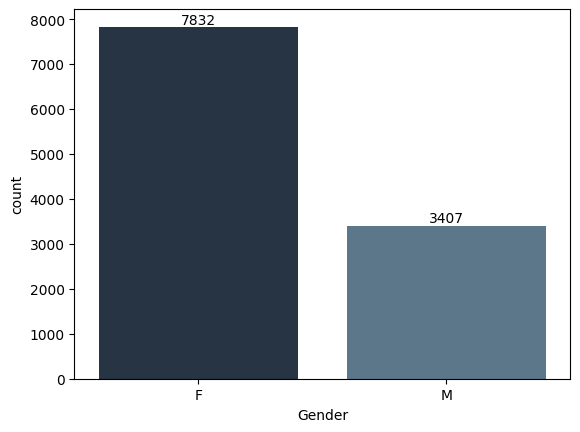

In [12]:
#plotting a bar chart for Gender and it's count
ax = sns.countplot(x = 'Gender',data = df , hue='Gender', legend=False , palette = ['#213448','#547792'])

for bars in ax.containers:
    ax.bar_label(bars)

## Gender vs Total Amount

<Axes: xlabel='Gender', ylabel='Amount'>

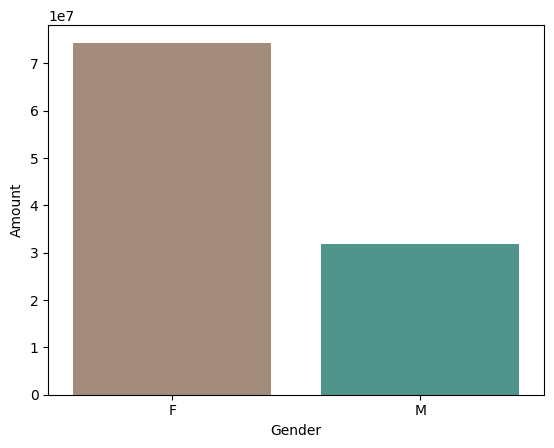

In [13]:
# plotting a bar chart for gender vs total amount
sales_gen = df.groupby(['Gender'],as_index = False)['Amount'].sum().sort_values(by = 'Amount',ascending = False)
sns.barplot(x = 'Gender', y = 'Amount', data = sales_gen,  hue='Gender',palette=['#A98B76', '#44A194'], legend=False)

-  From above graphs we can see that the most of the buyers are females and their purchasing power is also greater than men

## Age groups

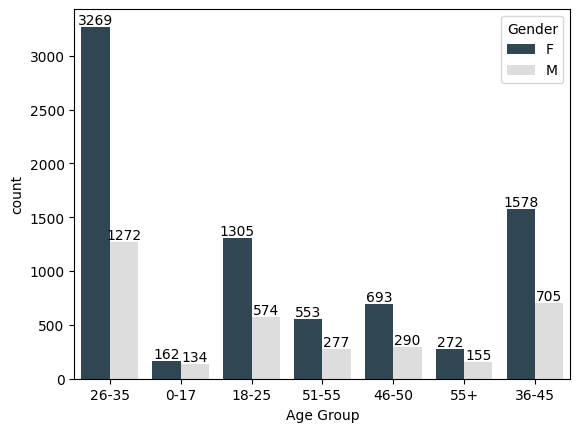

In [14]:
ax = sns.countplot(data = df, x = 'Age Group' , hue = 'Gender',palette = ['#2A4759','#DDDDDD'])

for bars in ax.containers:
    ax.bar_label(bars)

* Above graph shows that the most of the buyers group is from 26-35 age*

## Total amount vs age

<Axes: xlabel='Age Group', ylabel='Amount'>

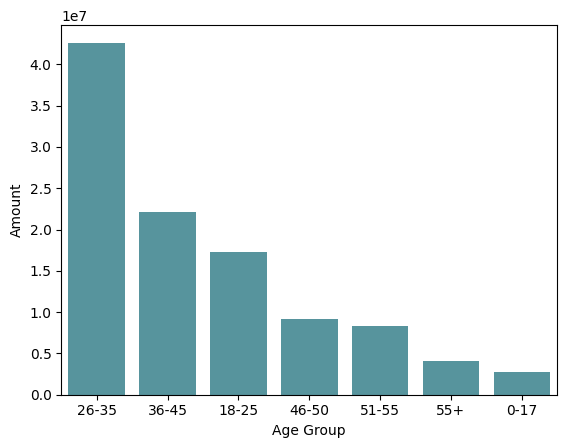

In [15]:
sales_age = df.groupby(['Age Group'], as_index = False)['Amount'].sum().sort_values(by = 'Amount',ascending = False)
sns.barplot(x = 'Age Group', y = 'Amount', data = sales_age, color = '#4B9DA9')

*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

## State

<Axes: xlabel='State', ylabel='Orders'>

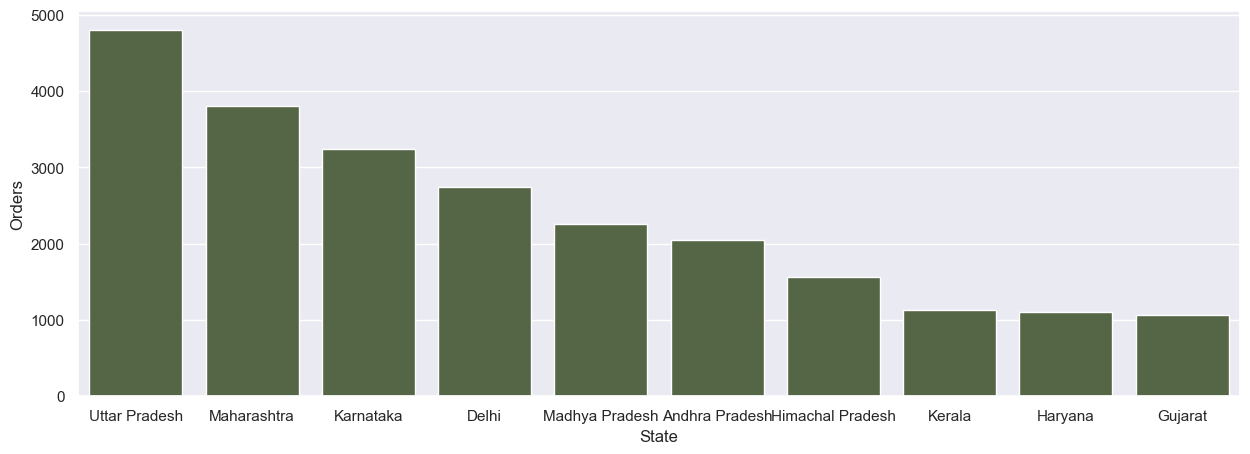

In [29]:
# total number of orders from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Orders' , color = '#546B41')

<i>Above graph shows the total number of orders from top 10 states</i>

## Total Amount/Sales

<Axes: xlabel='State', ylabel='Amount'>

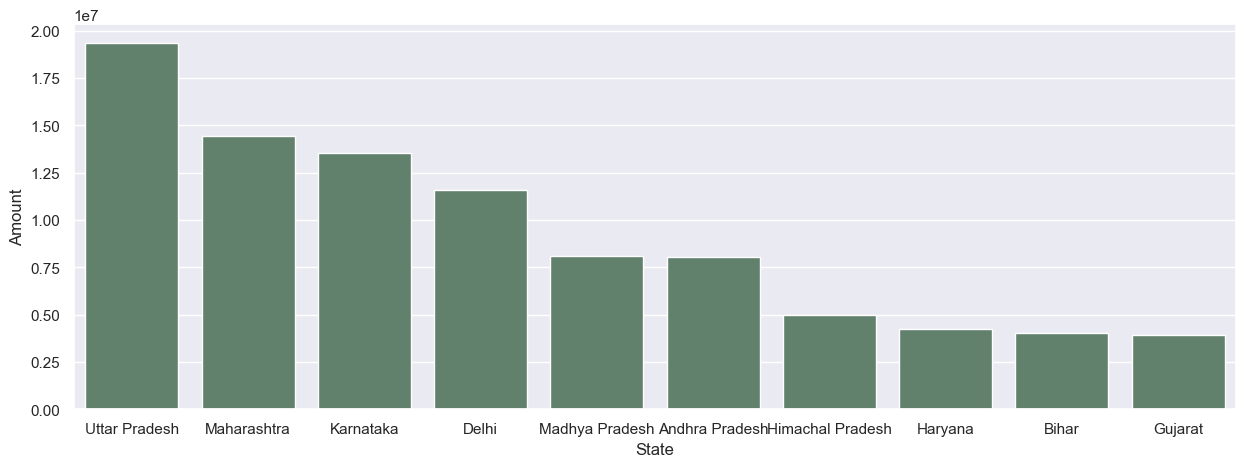

In [16]:
#total amount/sales from top 10 states
sales_state = df.groupby(['State'], as_index = False)['Amount'].sum().sort_values(by = 'Amount',ascending = False).head(10)
sns.set(rc= {'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State', y = 'Amount',color = '#5D866C')

*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*


## Marital Status

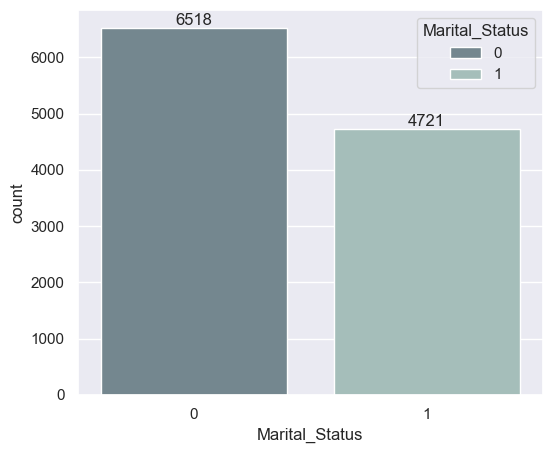

In [34]:
ax = sns.countplot(data = df, x = 'Marital_Status',hue = 'Marital_Status',palette = ['#708993','#A1C2BD'])

sns.set(rc={'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<i> Above graph shows that most of the buyers are married</i>

## Marital Status vs Amount

<Axes: xlabel='Marital_Status', ylabel='Amount'>

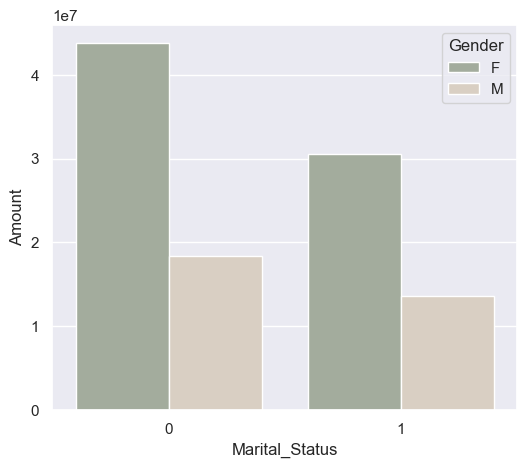

In [33]:
sales_state = df.groupby(['Marital_Status', 'Gender'],as_index = False)['Amount'].sum().sort_values(by = 'Amount',ascending = False)
sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status', y = 'Amount', hue = 'Gender',palette = ['#A2AF9B','#DCCFC0'])

<i>*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*</i>

## Occupation

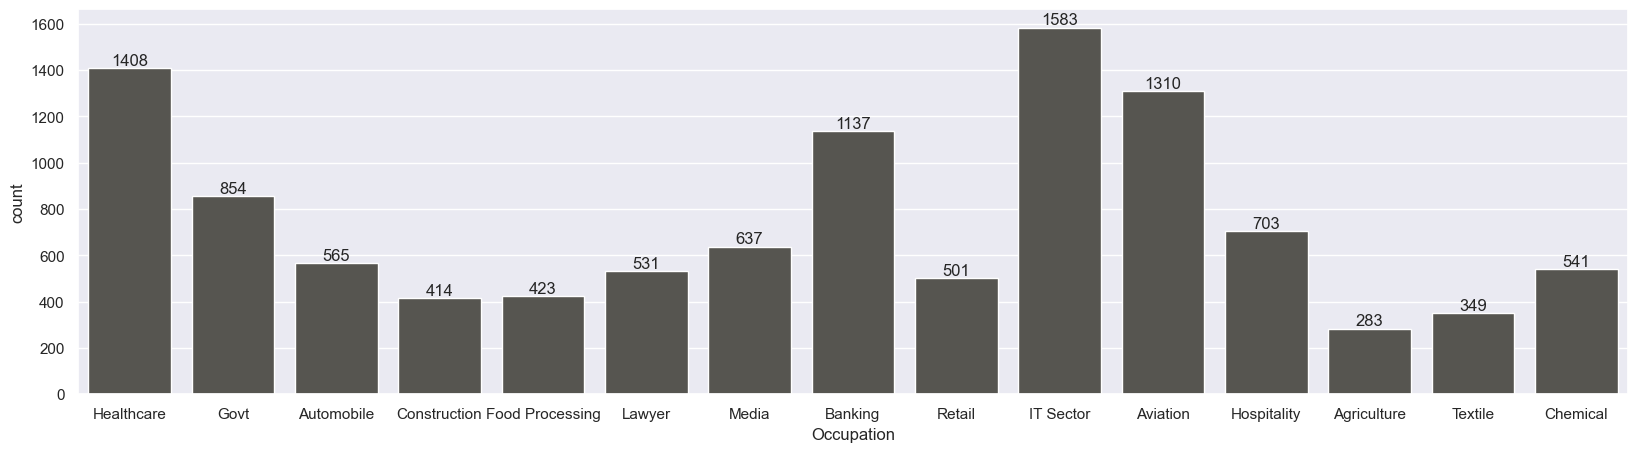

In [19]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation', color = '#57564F')

for bars in ax.containers:
    ax.bar_label(bars)

<i></i>

<Axes: xlabel='Occupation', ylabel='Amount'>

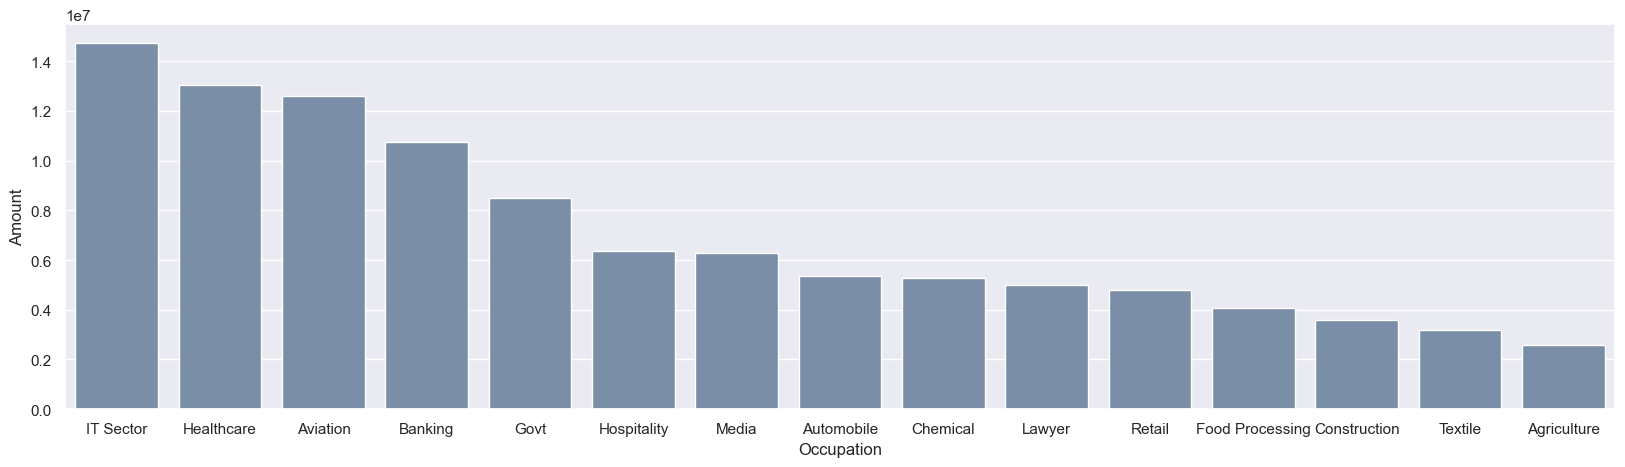

In [20]:
sales_state = df.groupby(['Occupation'],as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)

sns.set(rc = {'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation', y = 'Amount',color = '#748DAE')

In [21]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

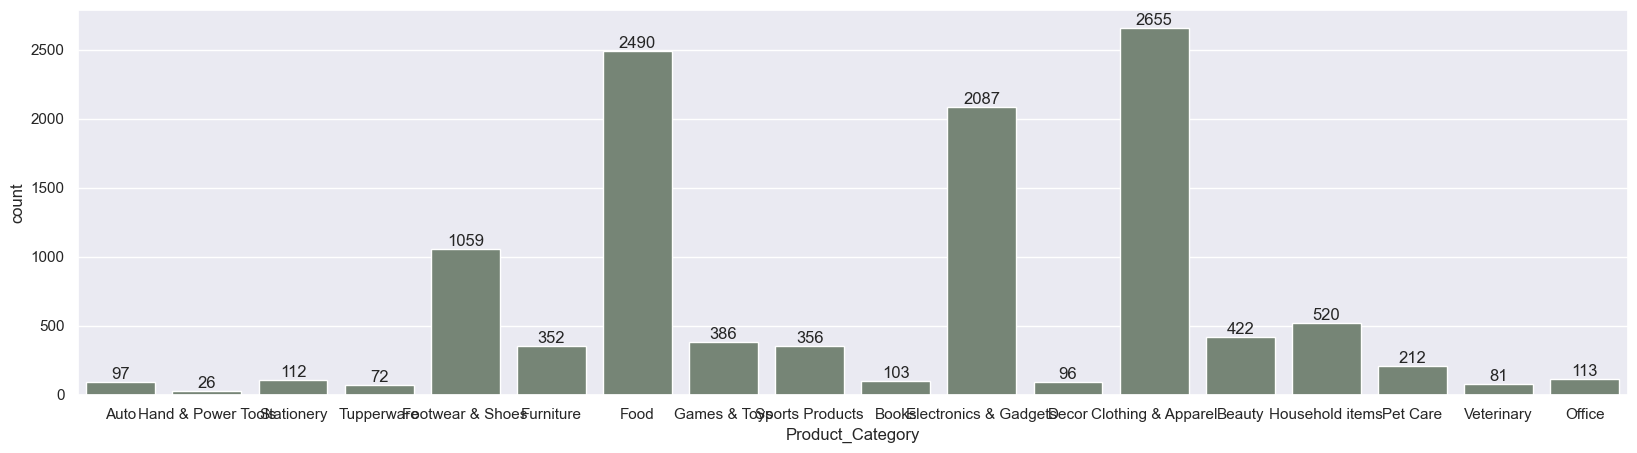

In [22]:
sns.set(rc = {'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Product_Category',color = '#748873')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

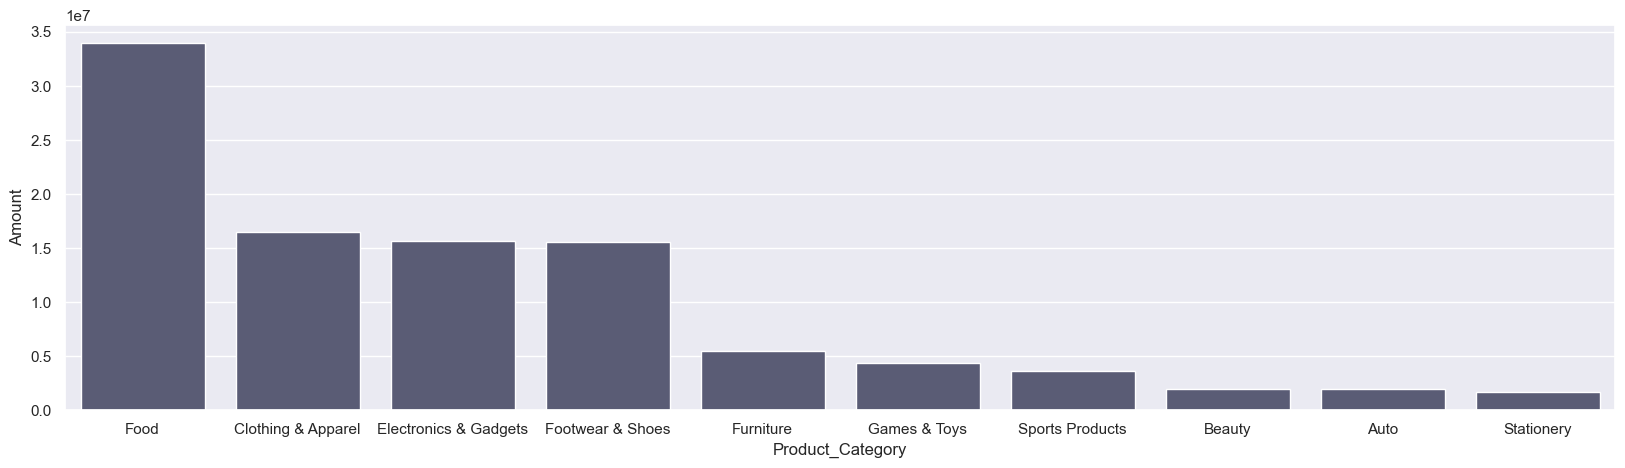

In [23]:
sales_state = df.groupby(['Product_Category'],as_index = False )['Amount'].sum().sort_values(by = 'Amount',ascending = False).head(10)

sns.set(rc = {'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category', y = 'Amount',color = '#555879')

<Axes: xlabel='Product_ID', ylabel='Orders'>

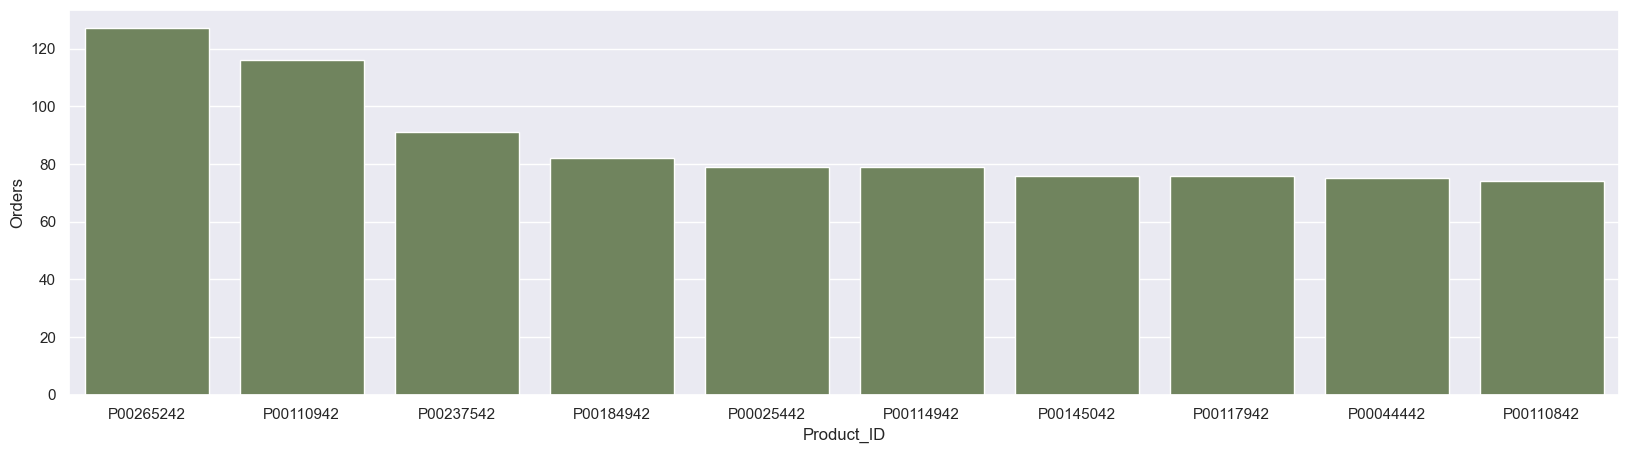

In [24]:
sales_state = df.groupby(['Product_ID'],as_index = False ) ['Orders'].sum().sort_values(by = 'Orders',ascending = False).head(10)

sns.set(rc = {'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID', y = 'Orders',color = '#708A58')

<Axes: xlabel='Product_ID'>

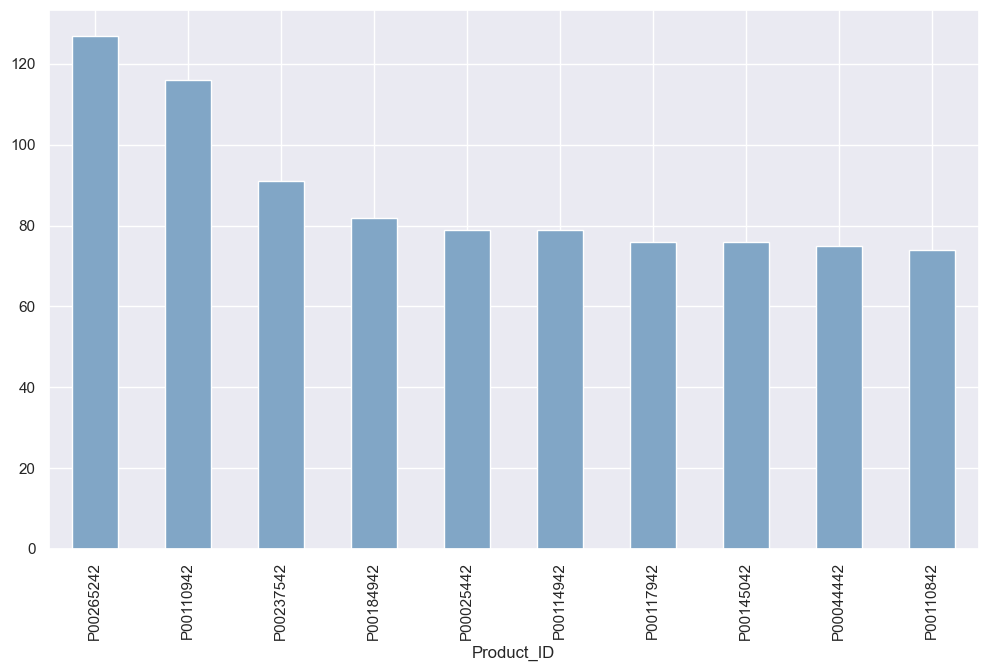

In [25]:
fig1, ax1 = plt.subplots(figsize =(12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending = False).plot(kind = 'bar',color = '#81A6C6')